In [ ]:
import os
from typing import Dict, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.multivariate_hawkes_training.lob_event_combinator import LOBEventCombinator

os.chdir(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes"
)


from src.lob_data_loader.lob_data_loader import LOBDataLoader
from src.lob_period.lob_period_extractor import LOBPeriodExtractor
from src.conf.events_conf.events_conf import EventsConf
from src.events_extractor.multivariate_lob_events_extractor import (
    MultivariateLOBEventsExtractor,
)


def get_conf(path: str) -> Dict:
    with open(path, "r") as f:
        conf = yaml.safe_load(f)
    return conf


def get_event_type_times_maps_with_combined_types(
    event_type_times_map: List[Dict[str, np.ndarray]],
    combined_name_events_to_combine_map: Dict[str, List[str]],
) -> List[Dict[str, np.ndarray]]:

    lob_event_combinator = LOBEventCombinator([event_type_times_map])

    for (
        combination_name,
        lob_events_to_combine,
    ) in combined_name_events_to_combine_map.items():
        event_type_times_maps = (
            lob_event_combinator.get_event_type_times_maps_with_new_combination(
                lob_events_to_combine,
                combination_name=combination_name,
            )
        )
        lob_event_combinator.event_type_times_maps = event_type_times_maps

    return event_type_times_maps


def get_event_type_times_maps_filtered(
    event_type_times_map: List[Dict[str, np.ndarray]], events_to_compute: List[str]
) -> List[Dict[str, np.ndarray]]:
    return [
        {
            key: value
            for key, value in event_type_times.items()
            if key in events_to_compute
        }
        for event_type_times in event_type_times_map
    ]


FILE_PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\dati\\hawkes\\orderbook_changes\\BTC_USD\\orderbook_changes_1705074061033.tsv"
CONF_EVENTS_PATH = "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\conf\\conf_events\\mid_price_change_events_conf.yml"

events_conf_map = get_conf(CONF_EVENTS_PATH)
events_conf = EventsConf.from_dict(events_conf_map)


lob_df_loader = LOBDataLoader()
lob_df = lob_df_loader.get_lob_dataframe(FILE_PATH, 10)

lob_period_extractor = LOBPeriodExtractor(lob_df)

start_time = lob_df["Timestamp"].min()

end_time = lob_df["Timestamp"].max()

lob_period = lob_period_extractor.get_lob_period(start_time, end_time)
lob_df_for_events = lob_period.get_lob_df_with_timestamp_column()

lob_df_for_events["Timestamp"] = lob_df_for_events["Timestamp"] * 1000

lob_events_extractor = MultivariateLOBEventsExtractor(
    lob_df_for_events,
    events_conf.num_levels_in_a_side,
    events_conf.num_levels_for_which_save_events,
)

event_type_times_map = lob_events_extractor.get_events()
event_type_times_map = {key.name: value for key, value in event_type_times_map.items()}

event_type_times_maps = get_event_type_times_maps_with_combined_types(
    event_type_times_map, events_conf.combined_event_types_map
)

event_type_times_maps = get_event_type_times_maps_filtered(
    event_type_times_maps, events_conf.events_to_compute
)

event_type_times_maps = [
    {
        key: [
            timestamps[i]
            for i in range(len(timestamps))
            if i == 0 or (timestamps[i] - timestamps[i - 1]) > 10
        ]
        for key, timestamps in event_dict.items()
    }
    for event_dict in event_type_times_maps
][0]

events_df = pd.DataFrame(
    [(k, v) for k, values in event_type_times_maps.items() for v in values],
    columns=["Event Type", "Event Time"],
)
rename_map = {
    "MID_PRICE_UP": "MP_UP",
    "MID_PRICE_DOWN": "MP_DOWN",
    "BUY_PRESSURE_UP": "BUY_P",
    "SELL_PRESSURE_UP": "SELL_P",
}
events_df["Event Type"] = events_df["Event Type"].map(rename_map)
events_df = events_df.sort_values("Event Time", ascending=True)
events_df["Offset Shared"] = events_df["Event Time"].diff()


def check_influence(event_x_df, event_y_df, median_offset):
    influenced_count = 0

    # For each event of type X, check if there is at least one event of type Y within the median offset
    for _, x_row in event_x_df.iterrows():
        # Get the time of event X
        x_time = x_row["Event Time"]

        # Check for events of type Y occurring within the median offset
        y_in_range = event_y_df[
            (event_y_df["Event Time"] > x_time)
            & (event_y_df["Event Time"] < x_time + median_offset)
        ]

        # If at least one Y event is found within the offset range, count it
        if not y_in_range.empty:
            influenced_count += 1

    # Return the proportion of events of type X influenced by event Y
    proportion_influenced = influenced_count / len(event_x_df)
    return proportion_influenced


median_offset = events_df["Offset Shared"].median()

influence_matrix = pd.DataFrame(
    index=events_conf.events_to_compute,
    columns=events_conf.events_to_compute,
    dtype=float,
)


"""for event_x in events_conf.events_to_compute:
    for event_y in events_conf.events_to_compute:
        proportion = check_influence(
            events_df[events_df["Event Type"] == event_x],
            events_df[events_df["Event Type"] == event_y],
            median_offset,
        )
        influence_matrix.at[event_y, event_x] = proportion

correlated_couples = influence_matrix > 0.06
correlated_couples = correlated_couples.flatten()

lower_bounds = np.concatenate(
    (
        mu_lower_bound * np.ones(len(events_conf.events_to_compute)),
        np.where(
            correlated_couples,
            rho_lower_bound * np.ones(len(events_conf.events_to_compute) ** 2),
            np.zeros(len(events_conf.events_to_compute) ** 2),
        ),
        np.where(
            correlated_couples,
            beta_lower_bound * np.ones(len(events_conf.events_to_compute) ** 2),
            100 * np.ones(len(events_conf.events_to_compute) ** 2),
        ),
    )
)

upper_bounds = np.concatenate(
    (
        mu_upper_bound * np.ones(len(events_conf.events_to_compute)),
        np.where(
            correlated_couples,
            rho_upper_bound * np.ones(len(events_conf.events_to_compute) ** 2),
            np.zeros(len(events_conf.events_to_compute) ** 2),
        ),
        np.where(
            correlated_couples,
            beta_upper_bound * np.ones(len(events_conf.events_to_compute) ** 2),
            100 * np.ones(len(events_conf.events_to_compute) ** 2),
        ),
    )
)"""

"""event_type_times_map_formatter = EventTypeTimesMapsFormatter()

event_type_times_formatted = (
    event_type_times_map_formatter.get_events_types_periods(
        event_type_times_maps, events_conf.events_to_compute
    )
)

event_type_times_formatted_in_seconds = [
    [times / 1000 for times in event_type_times]
    for event_type_times in event_type_times_formatted
]"""

'event_type_times_map_formatter = EventTypeTimesMapsFormatter()\n\nevent_type_times_formatted = (\n    event_type_times_map_formatter.get_events_types_periods(\n        event_type_times_maps, events_conf.events_to_compute\n    )\n)\n\nevent_type_times_formatted_in_seconds = [\n    [times / 1000 for times in event_type_times]\n    for event_type_times in event_type_times_formatted\n]'

In [4]:
minutes = (lob_df["Timestamp"].max() - lob_df["Timestamp"].min()) / (60 * 1e3)
print(f"minutes: {minutes}")

minutes: 0.05500331666469574


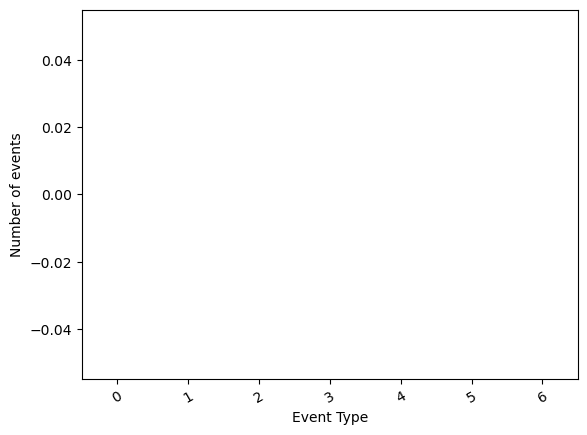

In [5]:
df_number_events = pd.DataFrame(
    list(
        {
            event_type: len(events)
            for event_type, events in event_type_times_maps.items()
        }.items()
    ),
    columns=["Event Type", "Number of events"],
)


df_number_events["Event Type"] = df_number_events["Event Type"].map(rename_map)
df_number_events = df_number_events.sort_values("Number of events", ascending=False)

sns.barplot(x="Event Type", y="Number of events", data=df_number_events)
plt.xticks(rotation=30)
plt.show()

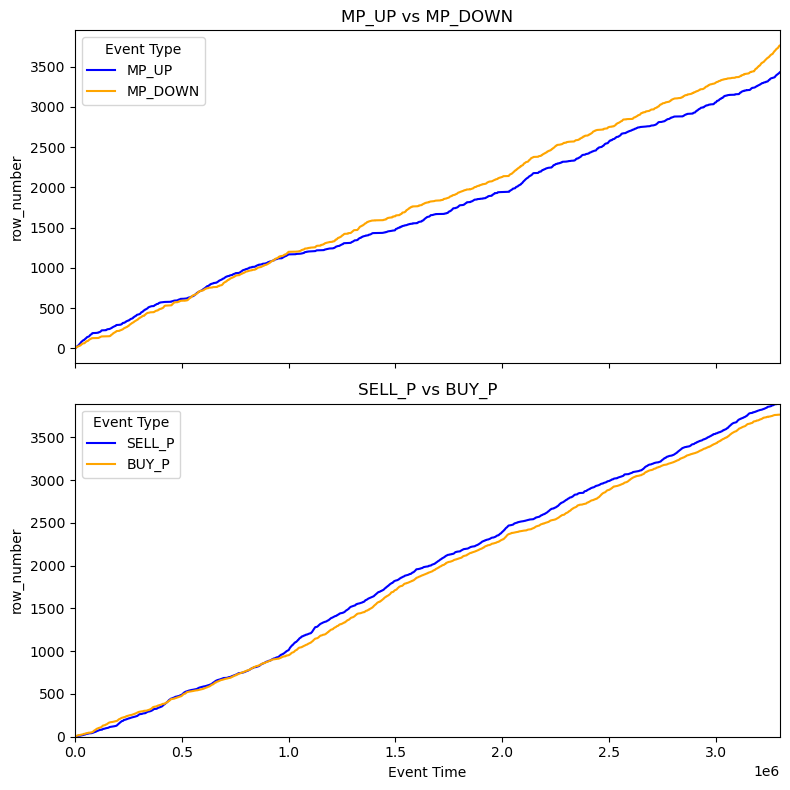

In [5]:
# Then try also a plot to see the distribuion of offsets (maybe a scatterplot).
# Then a scatterplot wih six y values (one for each event type) and x = time and a line that link them
events_df["row_number"] = events_df.groupby("Event Type").cumcount() + 1

event_groups = [
    ("MP_UP", "MP_DOWN"),
    ("SELL_P", "BUY_P"),
    # ("MAR_BID_N", "MAR_ASK_N"),
]

# Create subplots
fig, axes = plt.subplots(nrows=len(event_groups), ncols=1, figsize=(8, 8), sharex=True)

# Define colors
colors = ["blue", "orange"]

# Generate plots
for ax, (event1, event2) in zip(axes, event_groups):
    df_filtered = events_df[events_df["Event Type"].isin([event1, event2])]

    if not df_filtered.empty:  # Ensure the event types exist in the data
        sns.lineplot(
            data=df_filtered,
            x="Event Time",
            y="row_number",
            hue="Event Type",
            hue_order=[event1, event2],  # Ensure color consistency
            palette=colors,
            ax=ax,
        )
        ax.set_title(f"{event1} vs {event2}")
        plt.xlim(0, events_df["Event Time"].max())
        plt.ylim(0, events_df["row_number"].max())

# Adjust layout
plt.tight_layout()
plt.show()

<Axes: xlabel='Offset'>

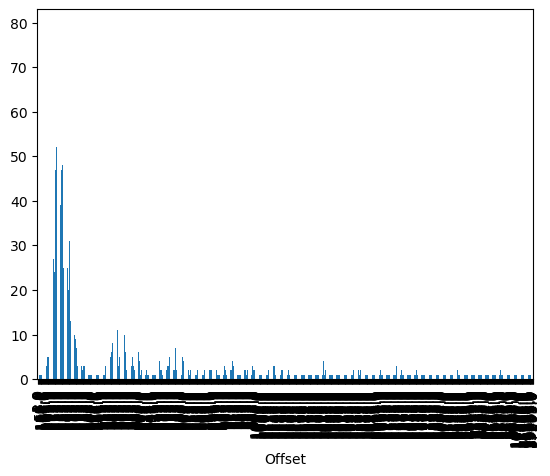

In [13]:
events_df[events_df["Event Type"] == "MP_UP"][
    "Offset"
].value_counts().sort_index().plot(kind="bar")

In [26]:
events_df[events_df["Event Type"] == "MP_DOWN"][
    "Offset"
].value_counts().sort_index().tail(20)

Offset
13345.0    1
13443.0    1
13703.0    1
14128.0    1
14221.0    1
14724.0    1
14751.0    1
15243.0    1
15786.0    1
15848.0    1
18917.0    1
19478.0    1
19950.0    1
20524.0    1
21658.0    1
22618.0    1
25310.0    1
28820.0    1
32940.0    1
35343.0    1
Name: count, dtype: int64

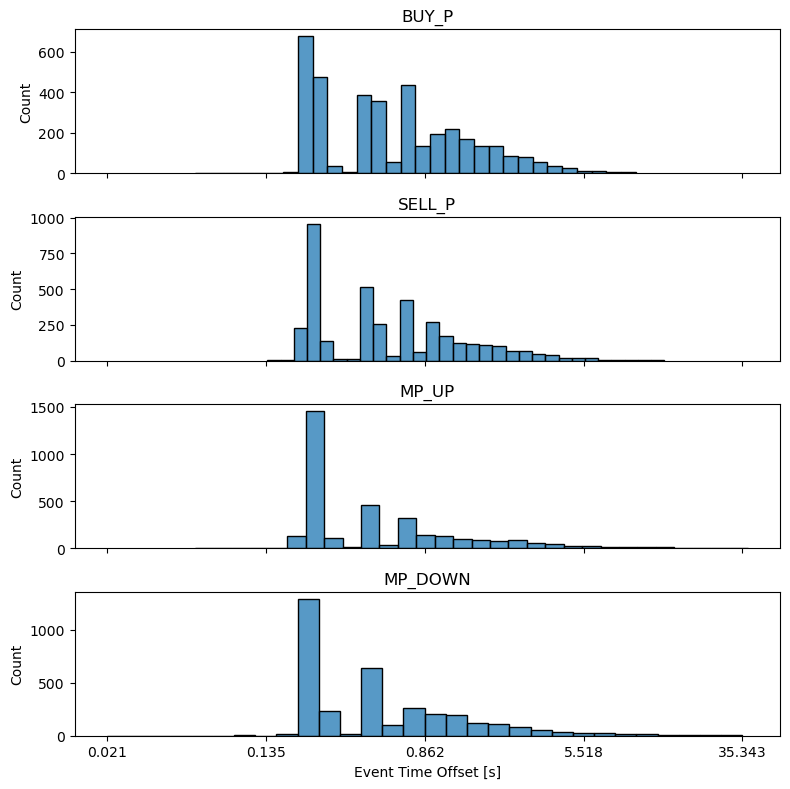

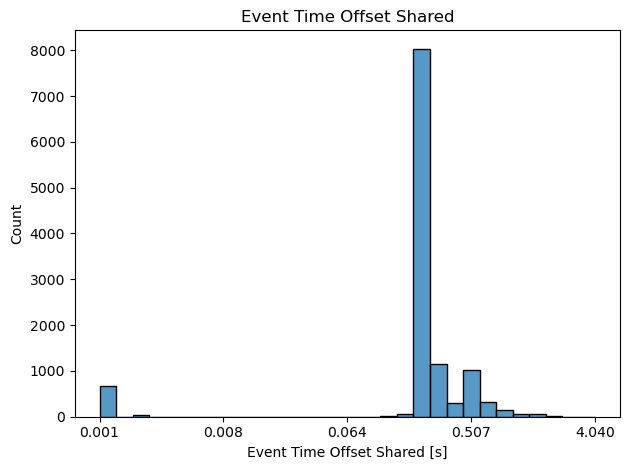

In [29]:
events_df["Offset"] = events_df.groupby("Event Type")["Event Time"].diff()
events_df["Offset Shared"] = events_df["Event Time"].sort_values(ascending=True).diff()
log_offset_shared = np.log(events_df[events_df["Offset Shared"] != 0]["Offset Shared"])
events_df["Log Offset"] = np.log(events_df["Offset"])

fig, axes = plt.subplots(
    nrows=len(events_df["Event Type"].unique()), ncols=1, figsize=(8, 8), sharex=True
)

for ax, event_type in zip(axes, events_df["Event Type"].unique()):
    df_filtered = events_df[events_df["Event Type"] == event_type]

    # remove outliers (values that are 5% bottom and 5% top)
    q_low = df_filtered["Log Offset"].quantile(0.05)
    q_hi = df_filtered["Log Offset"].quantile(0.95)
    # df_filtered = df_filtered[(df_filtered["Log Offset"] > q_low) & (df_filtered["Log Offset"] < q_hi)]
    # df_filtered = df_filtered[(df_filtered["Offset"] >= 3)]

    sns.histplot(df_filtered["Log Offset"], bins=30, ax=ax)

    ax.set_title(f"{event_type}")

    plt.xlabel("Event Time Offset [s]")
    plt.ylabel("Count")
    log_ticks = np.linspace(
        df_filtered["Log Offset"].min(), df_filtered["Log Offset"].max(), num=5
    )
    real_values = np.exp(log_ticks) / 1000

    plt.xticks(log_ticks, [f"{v:.3f}" for v in real_values])  # Format real values

plt.tight_layout()
plt.show()

log_offset_shared = log_offset_shared[(log_offset_shared != -np.inf)]
sns.histplot(
    log_offset_shared,
    bins=30,
)


plt.xlabel("Event Time Offset Shared [s]")
plt.ylabel("Count")
log_ticks = np.linspace(
    log_offset_shared.min(),
    log_offset_shared.max(),
    num=5,
)
real_values = np.exp(log_ticks) / 1000

plt.xticks(log_ticks, [f"{v:.3f}" for v in real_values])  # Format real values
plt.title("Event Time Offset Shared")
plt.tight_layout()
plt.show()

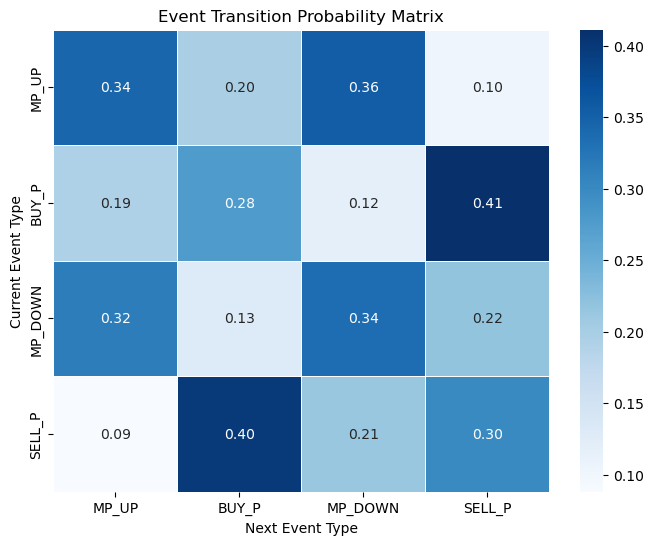

In [9]:
time_sorted_events_df = events_df.sort_values("Event Time")

time_sorted_events_df["Next Event Type"] = time_sorted_events_df["Event Type"].shift(-1)
transition_matrix = (
    time_sorted_events_df.groupby(["Event Type", "Next Event Type"])
    .size()
    .unstack(fill_value=0)
)

# Normalize rows to get transition probabilities
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

custom_order = ["MP_UP", "BUY_P", "MP_DOWN", "SELL_P"]
transition_matrix = transition_matrix.reindex(index=custom_order, columns=custom_order)


# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Event Transition Probability Matrix")
plt.xlabel("Next Event Type")
plt.ylabel("Current Event Type")
plt.show()

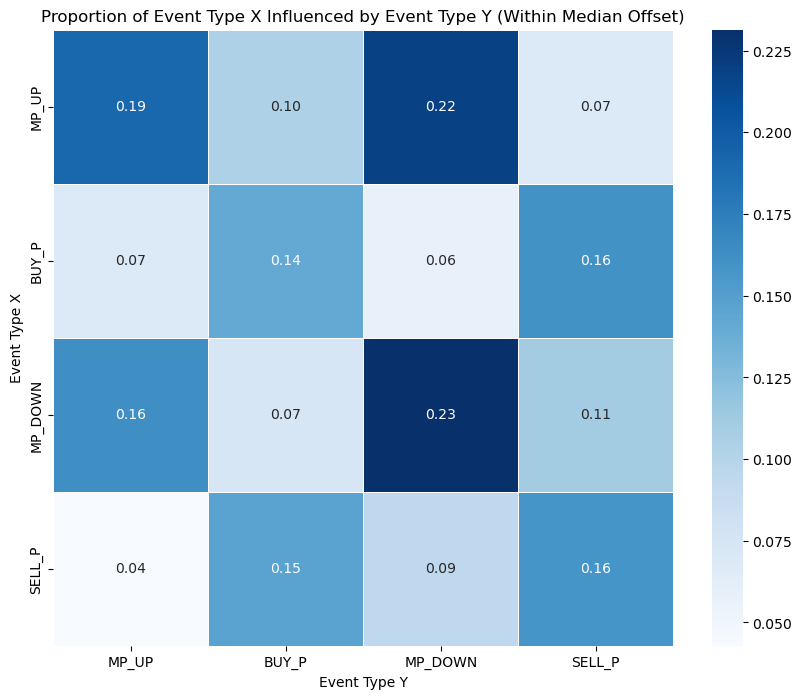

In [10]:
def check_influence(event_x_df, event_y_df, median_offset):
    influenced_count = 0

    # For each event of type X, check if there is at least one event of type Y within the median offset
    for _, x_row in event_x_df.iterrows():
        # Get the time of event X
        x_time = x_row["Event Time"]

        # Check for events of type Y occurring within the median offset
        y_in_range = event_y_df[
            (event_y_df["Event Time"] > x_time)
            & (event_y_df["Event Time"] < x_time + median_offset)
        ]

        # If at least one Y event is found within the offset range, count it
        if not y_in_range.empty:
            influenced_count += 1

    # Return the proportion of events of type X influenced by event Y
    proportion_influenced = influenced_count / len(event_x_df)
    return proportion_influenced


median_offset = events_df["Offset Shared"].median()

influence_matrix = pd.DataFrame(index=custom_order, columns=custom_order, dtype=float)


for event_x in custom_order:
    for event_y in custom_order:
        proportion = check_influence(
            events_df[events_df["Event Type"] == event_x],
            events_df[events_df["Event Type"] == event_y],
            median_offset,
        )
        influence_matrix.at[event_x, event_y] = proportion

# Step 5: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    influence_matrix.astype(float), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5
)
plt.title(
    "Proportion of Event Type X Influenced by Event Type Y (Within Median Offset)"
)
plt.xlabel("Event Type Y")
plt.ylabel("Event Type X")
plt.show()

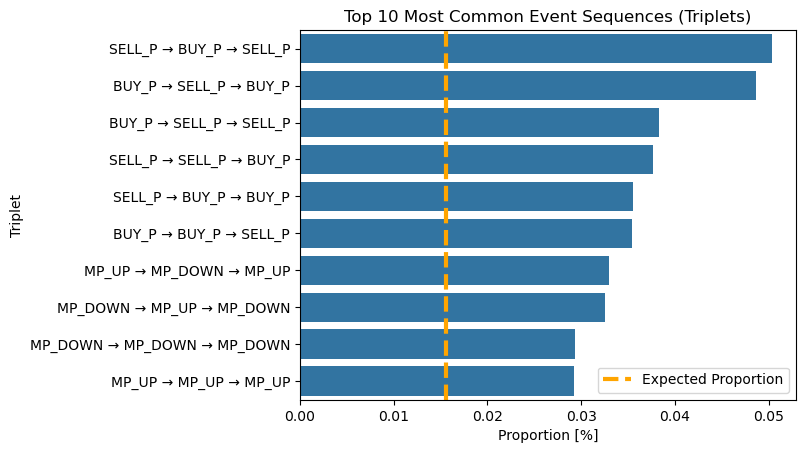

In [11]:
time_sorted_events_df["Next Event Type 2"] = time_sorted_events_df["Event Type"].shift(
    -2
)

# Drop NaN values (first two events won't have a full triplet)
triplets_df = time_sorted_events_df.dropna(
    subset=["Next Event Type", "Next Event Type 2"]
).copy()

# Create a column with the full sequence
triplets_df["Triplet"] = (
    triplets_df["Event Type"]
    + " → "
    + triplets_df["Next Event Type"]
    + " → "
    + triplets_df["Next Event Type 2"]
)

# Count occurrences
triplet_counts = triplets_df["Triplet"].value_counts().reset_index()
triplet_counts.columns = ["Triplet", "Count"]

total_triplets = triplet_counts["Count"].sum()
triplet_counts["Proportion"] = triplet_counts["Count"] / total_triplets

# Display the top sequences
sns.barplot(
    data=triplet_counts.head(10),
    y="Triplet",
    x="Proportion",
    legend=True,
)

# add a vertical line at average and add legend for it
plt.axvline(
    x=1 / (len(custom_order) ** 3),
    color="orange",
    linestyle="--",
    linewidth=3,
    label="Expected Proportion",
)

plt.legend()

plt.xlabel("Proportion [%]")
plt.title("Top 10 Most Common Event Sequences (Triplets)")
plt.show()